In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df_function = pd.read_excel("../data/01_FunctionAnalysis_data.xlsx")
df_force = pd.read_excel("../data/02_ForceAnalysis_data.xlsx")
df_torque = pd.read_excel("../data/03_TorqueAnalysis_Data.xlsx")
df_torque.rename(columns={"Paciente": "ID"}, inplace=True)

In [3]:
df_total_temp = df_function.merge(df_force, on=["ID", "Gender", "BMI_Value", "AgeGroup", "Clinical Treatment"])

df = df_total_temp.merge(df_torque, on=["ID", "Gender", "BMI_Value", "AgeGroup", "Clinical Treatment"])

df.columns, df.shape

(Index(['ID', 'Gender', 'BMI_Value', 'AgeGroup', 'Clinical Treatment',
        'tSTRIDE', 'tSTANCE', 'tSWING', 'tDBLSTANCE', 'velMEAN', 'fGRVE',
        'fGRAP', 'fGRML', 'fAML', 'fKML', 'fKAP', 'fKCP', 'fHPML', 'fHPAP',
        'fHPCP', 'tGRVE', 'tAFE', 'tKFE', 'tKAA', 'tKIE', 'tHPFE', 'tHPAA',
        'tHPIE'],
       dtype='str'),
 (81, 28))

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 28 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  81 non-null     int64  
 1   Gender              81 non-null     str    
 2   BMI_Value           81 non-null     str    
 3   AgeGroup            81 non-null     str    
 4   Clinical Treatment  81 non-null     str    
 5   tSTRIDE             81 non-null     float64
 6   tSTANCE             81 non-null     float64
 7   tSWING              81 non-null     float64
 8   tDBLSTANCE          81 non-null     float64
 9   velMEAN             81 non-null     float64
 10  fGRVE               81 non-null     float64
 11  fGRAP               81 non-null     float64
 12  fGRML               81 non-null     float64
 13  fAML                81 non-null     float64
 14  fKML                81 non-null     float64
 15  fKAP                81 non-null     float64
 16  fKCP                8

In [5]:
categorical_cols = ["ID", "Gender", "BMI_Value", "AgeGroup", "Clinical Treatment"]

numerical_cols = list(set(df.columns) - set(categorical_cols))

In [6]:
df[numerical_cols].describe()

,tGRVE,tHPFE,fGRAP,tKIE,fKCP,tHPAA,tSTANCE,tSWING,fGRVE,tDBLSTANCE,...,tSTRIDE,fKAP,fHPML,fKML,tAFE,fHPCP,fAML,tKAA,velMEAN,tKFE
count,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,...,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000
mean,-0.056840,0.219333,-7.913914,-0.009111,9.147531,0.653222,0.737556,0.440889,99.419852,0.156185,...,1.178963,0.708148,0.222284,0.802432,0.202630,7.762049,1.078457,0.391494,0.929173,0.095370
std,0.226014,0.243999,3.973958,0.030145,0.539429,0.151242,0.089332,0.036216,5.430512,0.043524,...,0.115589,0.565171,0.463117,0.616429,0.161076,0.470937,0.383196,0.132340,0.203342,0.237567
min,-0.559000,-0.356000,-18.869000,-0.080000,7.643000,0.310000,0.570000,0.360000,86.897000,0.090000,...,0.940000,-1.292000,-1.122000,-0.704000,-0.136000,6.632000,0.260000,0.132000,0.490000,-0.592000
25%,-0.223000,0.043000,-11.274000,-0.029000,8.838000,0.566000,0.680000,0.420000,96.027000,0.130000,...,1.110000,0.436000,-0.103000,0.407000,0.093000,7.380000,0.839000,0.288000,0.800000,-0.069000
50%,-0.039000,0.213000,-7.474000,-0.008000,9.069000,0.644000,0.710000,0.440000,98.896000,0.150000,...,1.160000,0.706000,0.222000,0.901000,0.196000,7.743000,1.064000,0.382000,0.938000,0.129000
75%,0.105000,0.401000,-4.536000,0.015000,9.395000,0.742000,0.780000,0.470000,101.943000,0.170000,...,1.240000,1.119000,0.612000,1.263000,0.270000,8.076000,1.262000,0.465000,1.044000,0.247000
max,0.377000,0.785000,0.117000,0.048000,10.856000,1.039000,1.000000,0.520000,117.109000,0.340000,...,1.450000,2.223000,1.179000,2.011000,0.660000,9.283000,2.342000,0.855000,1.365000,0.562000


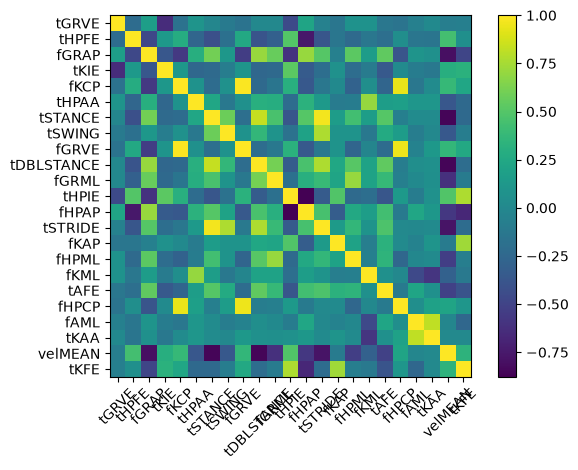

In [7]:
corr = df[numerical_cols].corr()

plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.tight_layout()
plt.show()

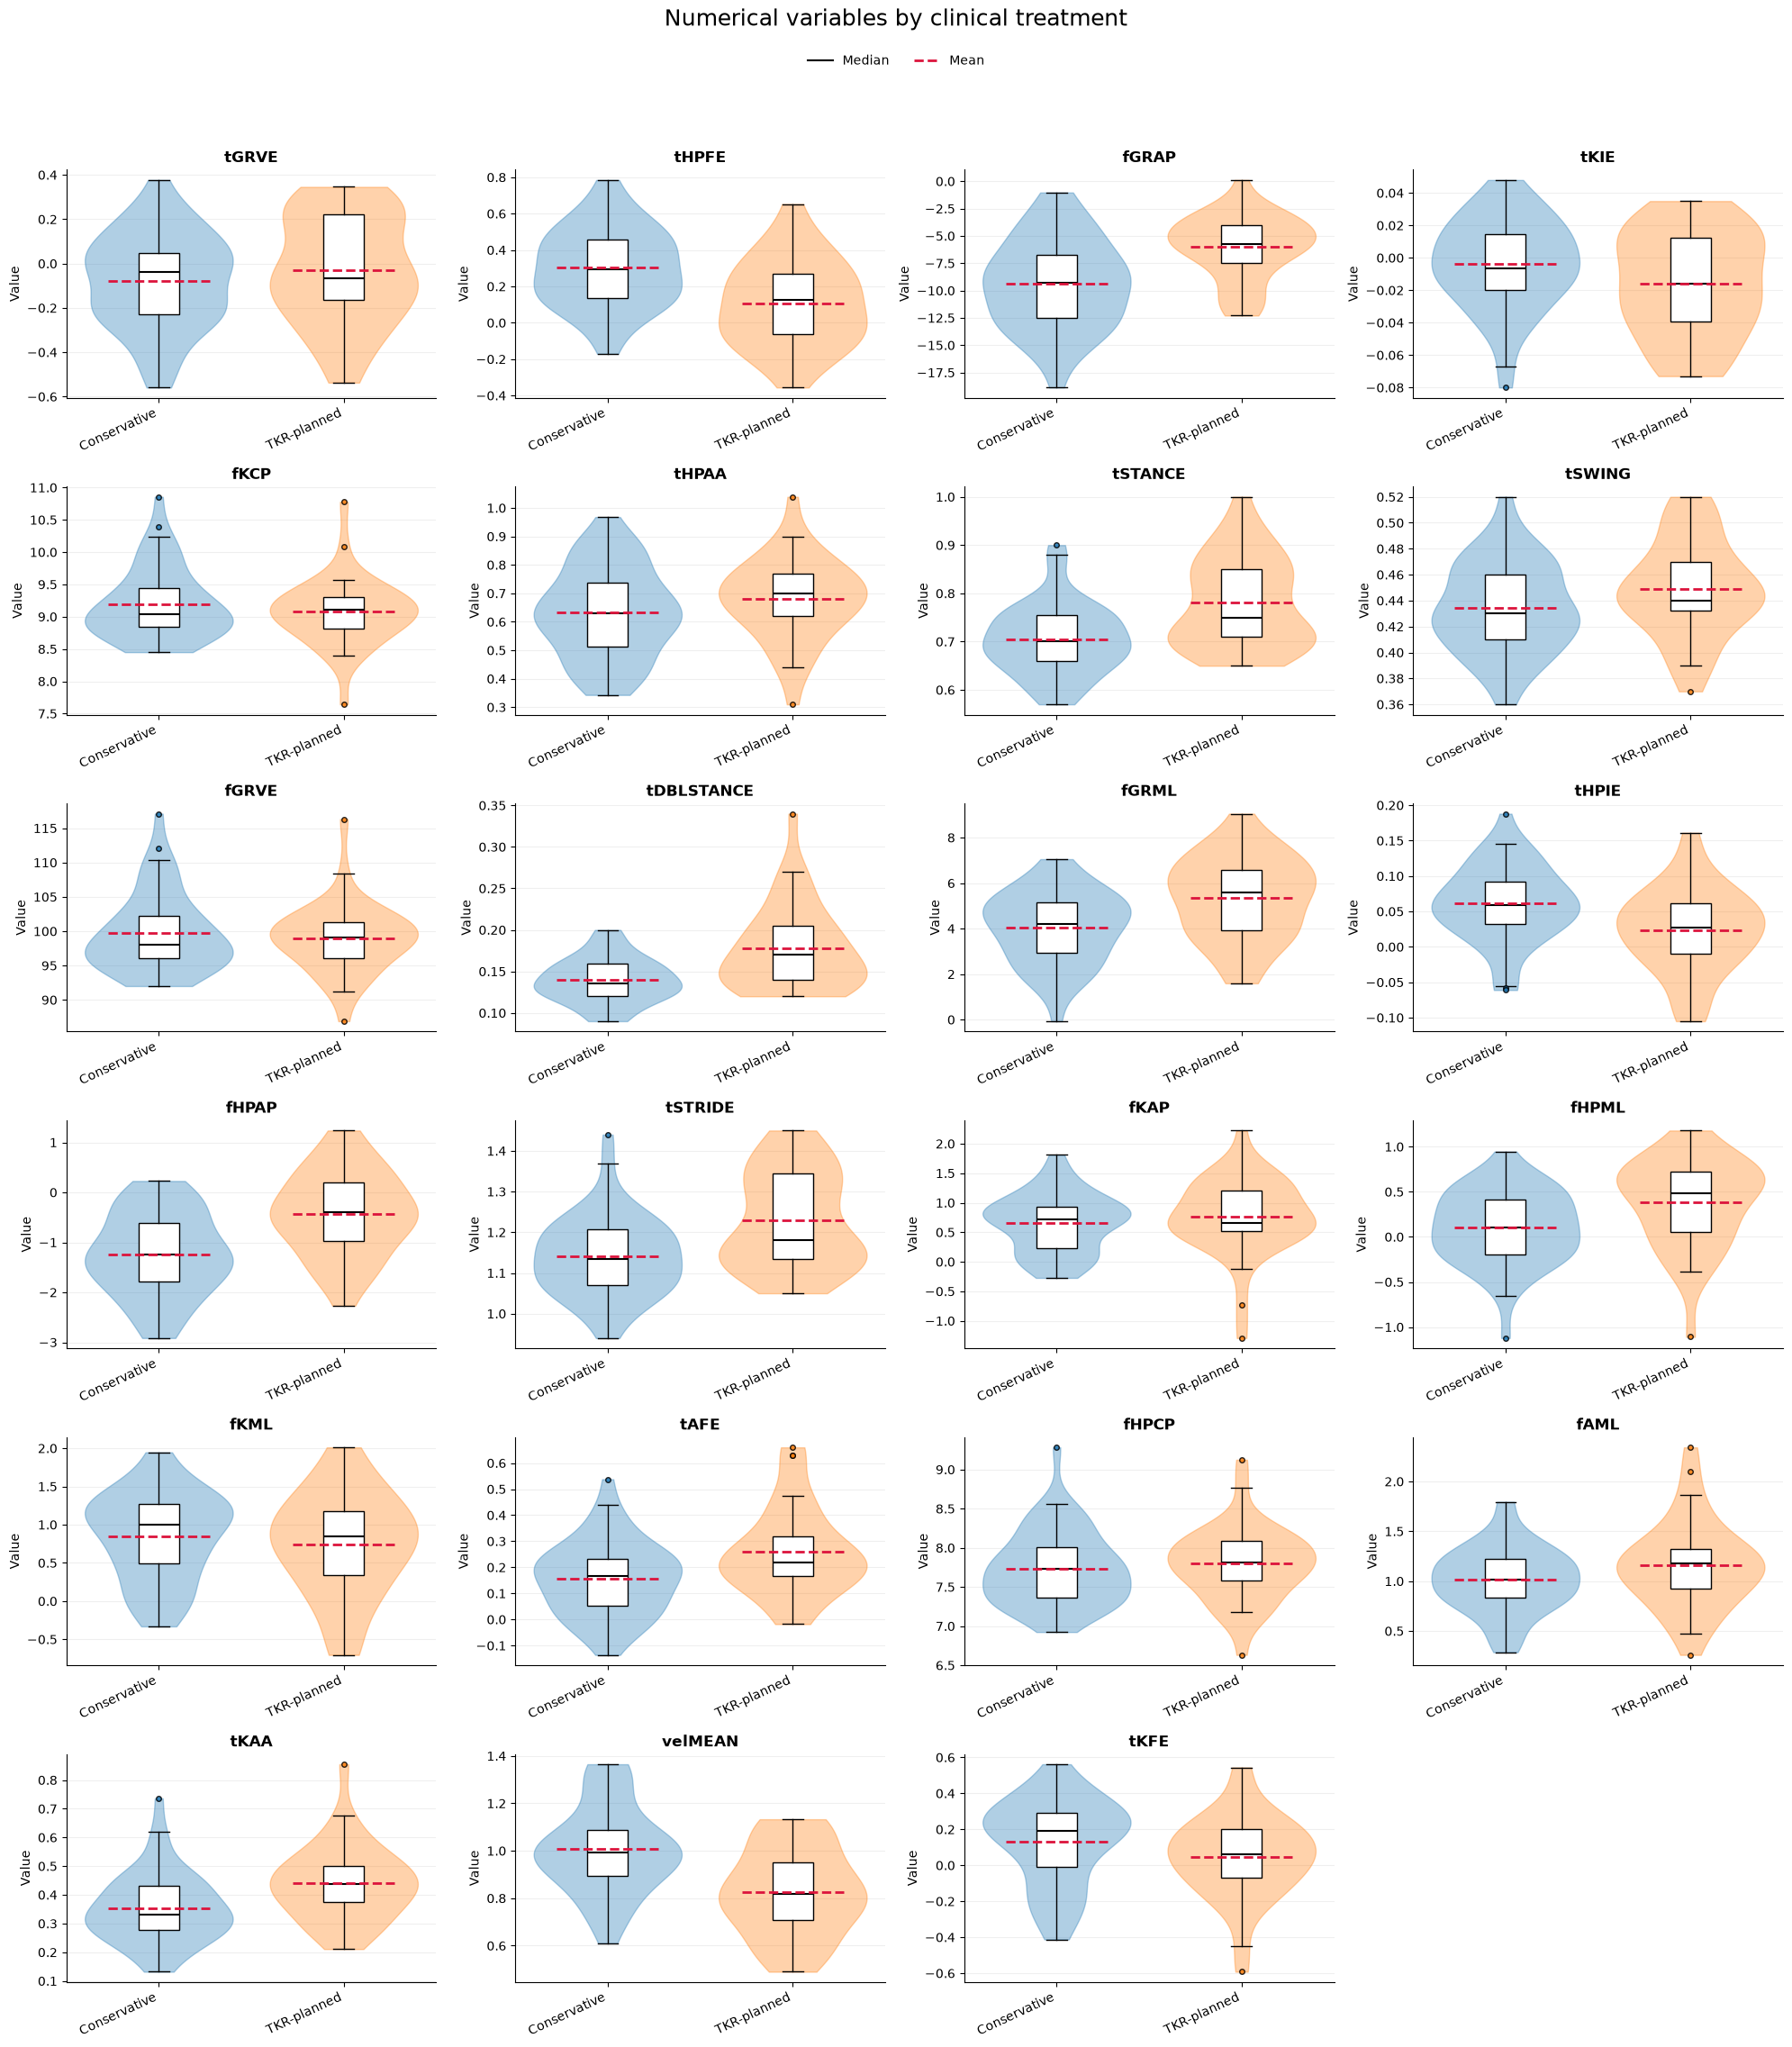

In [8]:
from matplotlib.lines import Line2D

treatments = list(df["Clinical Treatment"].dropna().unique())
colors = plt.get_cmap("tab10")(np.arange(len(treatments)) % 10)
ncols = 4
nrows = int(np.ceil(len(numerical_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 3.8 * nrows), squeeze=False)

for ax, col in zip(axes.flat, numerical_cols):
    for position, (treatment, color) in enumerate(zip(treatments, colors), start=1):
        values = df.loc[df["Clinical Treatment"] == treatment, col].dropna().to_numpy()
        values = values[np.isfinite(values)]
        if len(values) == 0:
            continue
        violin = ax.violinplot(
            [values], positions=[position], widths=0.8,
            showmeans=False, showmedians=False, showextrema=False,
        )
        for body in violin["bodies"]:
            body.set_facecolor(color)
            body.set_edgecolor(color)
            body.set_alpha(0.35)
        ax.boxplot(
            [values], positions=[position], widths=0.22,
            patch_artist=True, showfliers=True, manage_ticks=False,
            flierprops=dict(marker="o", markerfacecolor=color,
                            markeredgecolor="black", markersize=4, alpha=0.85),
            boxprops=dict(facecolor="white", edgecolor="black"),
            medianprops=dict(color="black", linewidth=1.5),
            zorder=3,
        )
        ax.hlines(values.mean(), position - 0.275, position + 0.275,
                  color="crimson", linestyle="--", linewidth=2, zorder=4)
    ax.set_title(col, fontsize=12, fontweight="bold")
    ax.set_xticks(range(1, len(treatments) + 1))
    ax.set_xticklabels([str(t) for t in treatments], rotation=25, ha="right")
    ax.set_xlim(0.5, len(treatments) + 0.5)
    ax.set_ylabel("Value")
    ax.grid(axis="y", alpha=0.2)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

for ax in axes.flat[len(numerical_cols):]:
    ax.remove()

fig.suptitle("Numerical variables by clinical treatment", fontsize=18, y=0.995)
fig.legend(handles=[
    Line2D([], [], color="black", linewidth=1.5, label="Median"),
    Line2D([], [], color="crimson", linestyle="--", linewidth=2, label="Mean"),
], loc="upper center", bbox_to_anchor=(0.5, 0.978), ncol=2, frameon=False)
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

# Does knee abduction-adduction moment differ according to Clinical Treatment and Gender, and is there a Clinical Treatment × Gender interaction?

**1. Gender differences exist in osteoarthritic gait (https://pubmed.ncbi.nlm.nih.gov/17239509/)**
- OA is more prevalent in females than males → background motivation for considering Gender.
- A significant Gender × OA-status interaction was found for knee flexion angle and knee moments in the sagittal, frontal and transverse planes. (indirect support only: OA vs healthy ≠ TKR vs Conservative)
- This study has found gait pattern differences between the genders in the osteoarthritic patients that were not apparent in the healthy subjects.

**2. Factors influencing knee adduction moment measurement: A systematic review and meta-regression analysis (https://pubmed.ncbi.nlm.nih.gov/28865395/)**
- Walking speed had the largest influence on knee adduction moment (p < 0.001). (walking speed could be adjusted for with ANCOVA/regression in a more complete analysis.)
- Participants with medial knee osteoarthritis had an increased knee adduction moment (p = 0.008) compared to healthy subjects.
- The studied moderators together explained about 60% of the heterogeneity in KAM results, showing that KAM is quite sensitive to methodological/patient-related factors and should not be interpreted in isolation.

## Hypotheses:

### Clinical Treatment
- (H_0): Mean tKAA does not differ between the TKR and Conservative groups.
- (H_1): Mean tKAA differs between the TKR and Conservative groups.
### Gender
- (H_0): Mean tKAA does not differ between genders.
- (H_1): Mean tKAA differs between genders.
### Interaction
- (H_0): There is no interaction between Clinical Treatment and Gender on tKAA.
- (H_1): There is an interaction between Clinical Treatment and Gender on tKAA.

## Other possible papers to read:

**The association of external knee adduction moment with biomechanical variables in osteoarthritis: A systematic review (https://www.thekneejournal.com/article/S0968-0160%2808%2900240-8/fulltext)**

**Sex differences in knee joint loading: Cross-sectional study in geriatric population (https://onlinelibrary.wiley.com/doi/abs/10.1002/jor.23374)**

**Can exercise interventions reduce external knee adduction moment during gait? A systematic review and meta-analysis (https://pubmed.ncbi.nlm.nih.gov/37672821/)**

**Gender differences in gait kinematics for patients with knee osteoarthritis (https://pmc.ncbi.nlm.nih.gov/articles/PMC4830067/)**

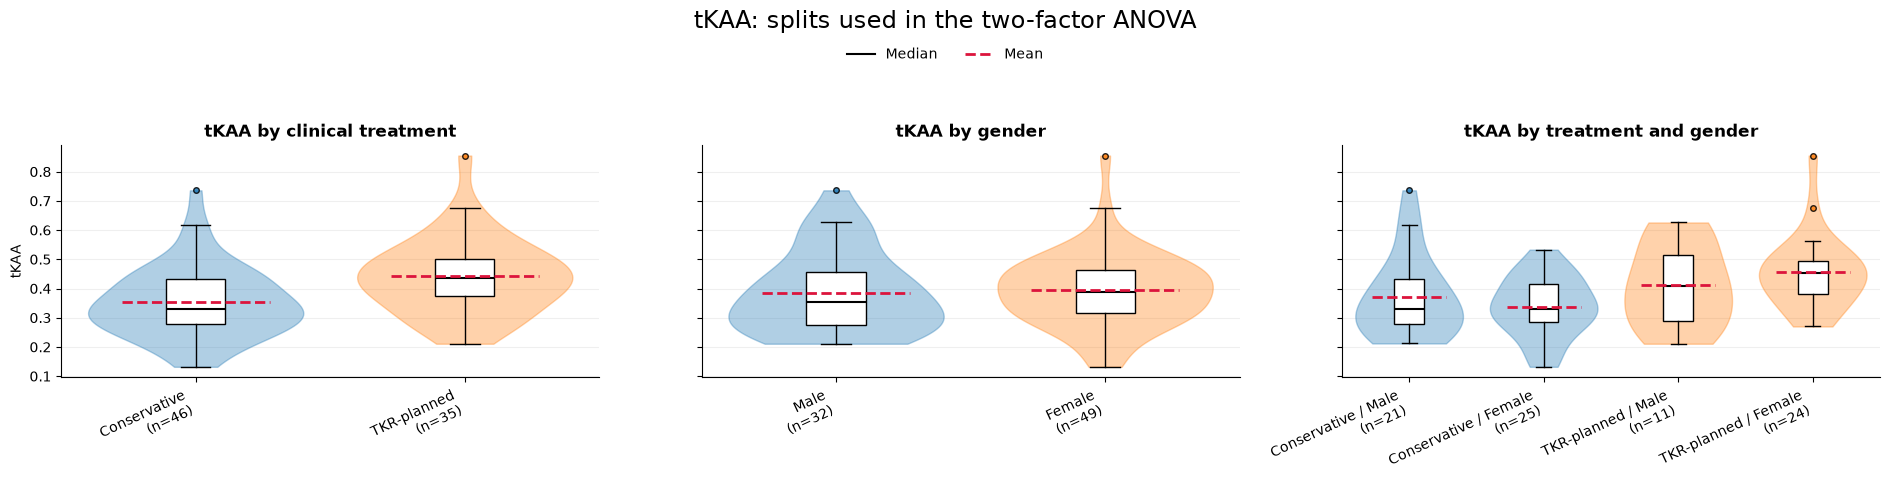

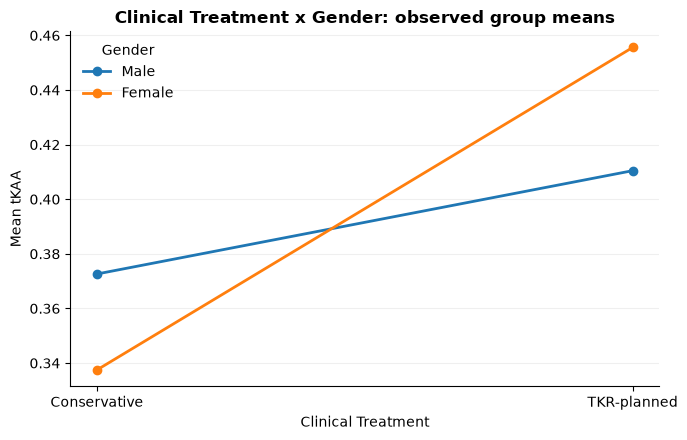

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Use the same complete, finite observations as the two-factor ANOVA.
plot_df = df[["tKAA", "Clinical Treatment", "Gender"]].dropna().copy()
plot_df = plot_df.loc[np.isfinite(plot_df["tKAA"])]
treatments = list(plot_df["Clinical Treatment"].unique())
genders = list(plot_df["Gender"].unique())
treatment_colors = plt.get_cmap("tab10")(np.arange(len(treatments)) % 10)
gender_colors = plt.get_cmap("tab10")(np.arange(len(genders)) % 10)
fig, axes = plt.subplots(1, 3, figsize=(19, 5), sharey=True)

# Treatment, gender, and all Treatment x Gender combinations.
groups = [
    [(str(t), plot_df.loc[plot_df["Clinical Treatment"] == t, "tKAA"].to_numpy(), color)
     for t, color in zip(treatments, treatment_colors)],
    [(str(g), plot_df.loc[plot_df["Gender"] == g, "tKAA"].to_numpy(), color)
     for g, color in zip(genders, gender_colors)],
    [(f"{t} / {g}", plot_df.loc[(plot_df["Clinical Treatment"] == t)
                              & (plot_df["Gender"] == g), "tKAA"].to_numpy(), color)
     for t, color in zip(treatments, treatment_colors) for g in genders],
]
for ax, panel_groups, title in zip(axes, groups, [
    "tKAA by clinical treatment", "tKAA by gender", "tKAA by treatment and gender"
]):
    labels = []
    for position, (label, values, color) in enumerate(panel_groups, start=1):
        labels.append(f"{label}\n(n={len(values)})")
        if len(values) == 0:
            continue
        # A violin needs more than one value and nonzero variation.
        if len(values) > 1 and np.ptp(values) > 0:
            violin = ax.violinplot(
                [values], positions=[position], widths=0.8,
                showmeans=False, showmedians=False, showextrema=False,
            )
            for body in violin["bodies"]:
                body.set_facecolor(color)
                body.set_edgecolor(color)
                body.set_alpha(0.35)
        ax.boxplot(
            [values], positions=[position], widths=0.22,
            patch_artist=True, showfliers=True, manage_ticks=False,
            flierprops=dict(marker="o", markerfacecolor=color,
                            markeredgecolor="black", markersize=4, alpha=0.85),
            boxprops=dict(facecolor="white", edgecolor="black"),
            medianprops=dict(color="black", linewidth=1.5), zorder=3,
        )
        ax.hlines(values.mean(), position - 0.275, position + 0.275,
                  color="crimson", linestyle="--", linewidth=2, zorder=4)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xticks(range(1, len(panel_groups) + 1))
    ax.set_xticklabels(labels, rotation=25, ha="right")
    ax.set_xlim(0.5, len(panel_groups) + 0.5)
    ax.grid(axis="y", alpha=0.2)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("tKAA")
fig.suptitle("tKAA: splits used in the two-factor ANOVA", fontsize=17)
fig.legend(handles=[
    Line2D([], [], color="black", linewidth=1.5, label="Median"),
    Line2D([], [], color="crimson", linestyle="--", linewidth=2, label="Mean"),
], loc="upper center", bbox_to_anchor=(0.5, 0.93), ncol=2, frameon=False)
fig.tight_layout(rect=(0, 0, 1, 0.86))
plt.show()

# Interaction plot: compare the treatment difference within each gender.
fig, ax = plt.subplots(figsize=(7, 4.5))
for gender, color in zip(genders, gender_colors):
    means = [plot_df.loc[(plot_df["Clinical Treatment"] == treatment)
                        & (plot_df["Gender"] == gender), "tKAA"].mean()
             for treatment in treatments]
    ax.plot(range(len(treatments)), means, marker="o", linewidth=2,
            color=color, label=str(gender))
ax.set_xticks(range(len(treatments)))
ax.set_xticklabels([str(t) for t in treatments])
ax.set_xlabel("Clinical Treatment")
ax.set_ylabel("Mean tKAA")
ax.set_title("Clinical Treatment x Gender: observed group means", fontweight="bold")
ax.legend(title="Gender", frameon=False)
ax.grid(axis="y", alpha=0.2)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()
# Nonparallel lines suggest an interaction visually; use the ANOVA p-value to test it.
# The pooled plots weight groups by sample size; Type III main effects use equal weighting.
